<a href="https://colab.research.google.com/github/DevGaonkar/project-0/blob/main/AIDSMemb6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-9

def approx_equal(a, b, tol=1e-6):
    return np.allclose(a, b, atol=tol, rtol=0)

def is_subset(A, B):
    return np.all(A <= B + EPS)

def show(title, xs, *series_with_labels):
    plt.figure()
    for (y, lbl) in series_with_labels:
        plt.plot(xs, y, label=lbl)
    plt.xlabel("Domain x")
    plt.ylabel("Membership μ")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def triangular_mf(x, a, b, c):
    left = (x - a) / (b - a + EPS)
    right = (c - x) / (c - b + EPS)
    return np.maximum(np.minimum(left, right), 0.0).clip(0, 1)

def trapezoidal_mf(x, a, b, c, d):
    left = (x - a) / (b - a + EPS)
    right = (d - x) / (d - c + EPS)
    return np.maximum(np.minimum.reduce([left, np.ones_like(x), right]), 0.0).clip(0, 1)

def gaussian_mf(x, m, sigma):
    return np.exp(-0.5 * ((x - m) / (sigma + EPS))**2).clip(0, 1)

def singleton_mf(x, x0):
    idx = np.argmin(np.abs(x - x0))
    y = np.zeros_like(x)
    y[idx] = 1.0
    return y

def constant_mf(x, c):
    return np.full_like(x, float(c))

In [ ]:
X = np.linspace(0, 10, 201)

In [ ]:
A = triangular_mf(X, a=2, b=5, c=8)
B = trapezoidal_mf(X, a=1, b=3, c=7, d=9)

G = gaussian_mf(X, m=5, sigma=1.2)
S = singleton_mf(X, x0=7.0)
C = constant_mf(X, c=0.6)

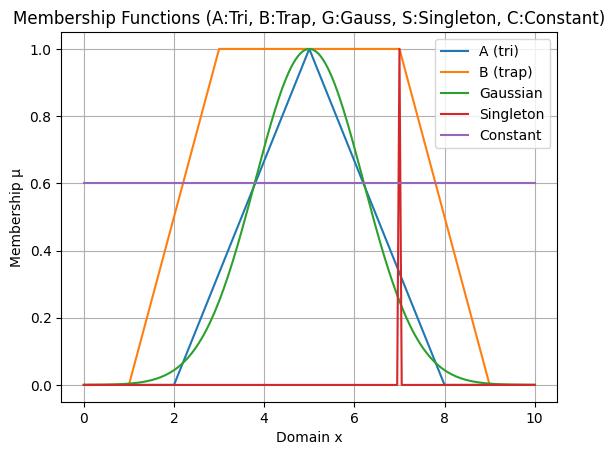

In [ ]:
show("Membership Functions (A:Tri, B:Trap, G:Gauss, S:Singleton, C:Constant)",
     X, (A,"A (tri)"), (B,"B (trap)"), (G,"Gaussian"), (S,"Singleton"), (C,"Constant"))


In [ ]:
def fuzzy_union(A, B):
    return np.maximum(A, B)

def fuzzy_intersection(A, B):
    return np.minimum(A, B)

def fuzzy_complement(A):
    return 1.0 - A

U = fuzzy_union(A, B)
I = fuzzy_intersection(A, B)
Ac = fuzzy_complement(A)
Bc = fuzzy_complement(B)


In [ ]:
def support(mu, eps=1e-6):
    return X[mu > eps]

def core(mu, eps=1e-6):
    return X[mu >= 1.0 - eps]

def boundary(mu, eps=1e-6):
    sup = mu > eps
    cor = mu >= 1.0 - eps
    return X[np.logical_and(sup, ~cor)]

print("A: |support|, |core|, |boundary| =", len(support(A)), len(core(A)), len(boundary(A)))
print("B: |support|, |core|, |boundary| =", len(support(B)), len(core(B)), len(boundary(B)))


A: |support|, |core|, |boundary| = 119 1 118
B: |support|, |core|, |boundary| = 159 81 78


In [ ]:
from copy import deepcopy

global ClassA
ClassA = [[0.7, 'Ninad'], [0.2, 'Krishna'], [0.4, 'Shalaka'], [0.3, 'Isha']]

global ClassB
ClassB = [[0.8, 'Ninad'], [0.4, 'Krishna'], [0.3, 'Shalaka'], [0.2, 'Isha'], [0.5, 'Jisha']]
def union(setA, setB):
    X, Y = deepcopy(setA), deepcopy(setB)
    Z = []
    for i in X:
        k = checkElementHelper(i[1], Y)
        if k != -1:
            Z.append([max(i[0], Y[k][0]), i[1]])
            Y.remove(Y[k])
        else:
            Z.append(i)
    Z = Z + Y
    return Z
def intersection(setA, setB):
    X, Y = deepcopy(setA), deepcopy(setB)
    Z = []
    for i in X:
        k = checkElementHelper(i[1], Y)
        if k != -1:
            Z.append([min(i[0], Y[k][0]), i[1]])
            Y.remove(Y[k])
    return Z
def complement(setA):
    Z = []
    for i in setA:
        Z.append([1 - i[0], i[1]])
    return Z
def checkElementHelper(e, setA):
    for i in range(len(setA)):
        if setA[i][1] == e:
            return i
    return -1
print("union property :",union(ClassA,ClassB))
print("Interseca")